# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [5]:
filename = "/Users/anoob/Downloads/supersymmetry_dataset.csv"
VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta",
            "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
            "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames, header=0)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [6]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [8]:
#Train-Test Split

N_Train = 4000000

Train_Sample = df[:N_Train]
Test_Sample  = df[N_Train:]

raw_features  = VarNames[1:8]   # low-level: l_1_pT ... MET
high_features = VarNames[8:]    # high-level: MET_phi, MET_rel, axial_MET, M_R, ...
all_features  = VarNames[1:]    # everything

X_Train = Train_Sample[all_features]
y_Train = Train_Sample["signal"]

X_Test = Test_Sample[all_features]
y_Test = Test_Sample["signal"]

Test_sig = Test_Sample[Test_Sample.signal == 1]
Test_bkg = Test_Sample[Test_Sample.signal == 0]

We can train the classifier as follow:

In [9]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

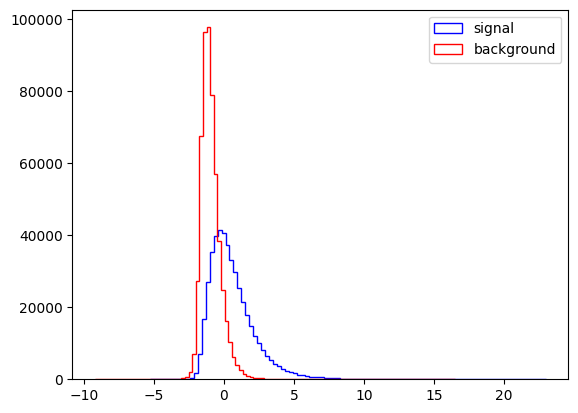

In [10]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

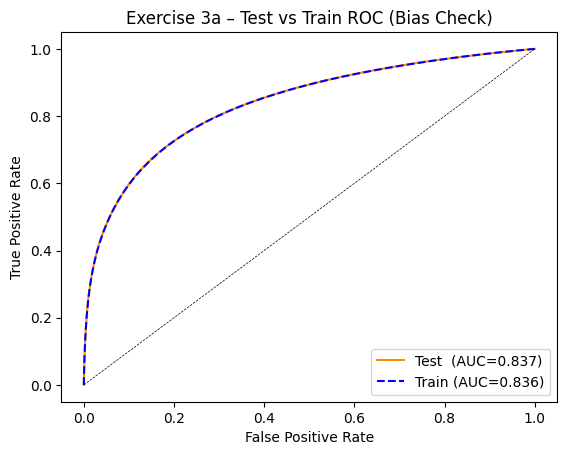

In [11]:
from sklearn.metrics import roc_curve, auc

fpr_test,  tpr_test,  _ = roc_curve(y_Test,  Fisher.decision_function(X_Test))
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))

auc_test  = auc(fpr_test,  tpr_test)
auc_train = auc(fpr_train, tpr_train)

plt.figure()
plt.plot(fpr_test,  tpr_test,  color='darkorange', label=f'Test  (AUC={auc_test:.3f})')
plt.plot(fpr_train, tpr_train, color='blue', linestyle='--', label=f'Train (AUC={auc_train:.3f})')
plt.plot([0,1],[0,1], 'k--', linewidth=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exercise 3a – Test vs Train ROC (Bias Check)')
plt.legend(loc='lower right')
plt.show()

They basically overlap each other.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot.

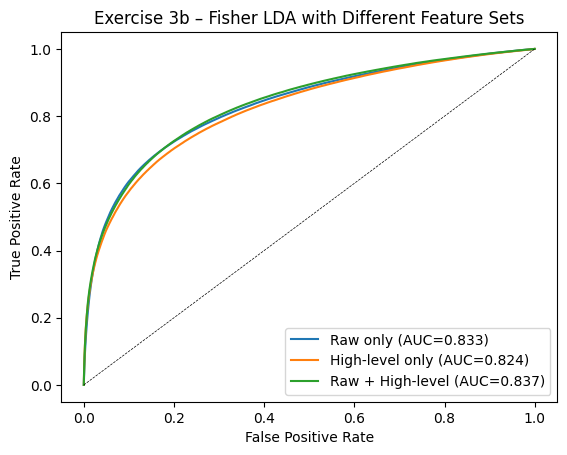

In [13]:
feature_sets = {
    "Raw only"        : raw_features,
    "High-level only" : high_features,
    "Raw + High-level": all_features,
}

plt.figure()
for label, feats in feature_sets.items():
    clf = DA.LinearDiscriminantAnalysis()
    clf.fit(Train_Sample[feats], y_Train)
    fpr, tpr, _ = roc_curve(y_Test, clf.decision_function(Test_Sample[feats]))
    plt.plot(fpr, tpr, label=f'{label} (AUC={auc(fpr, tpr):.3f})')

plt.plot([0,1],[0,1], 'k--', linewidth=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exercise 3b – Fisher LDA with Different Feature Sets')
plt.legend(loc='lower right')
plt.show()

Raw perfroms slightly better which is suprising but as all of them are pretty close to each other LDA has hit its ceiling and we have to try different methods.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

4a. Chosen classifiers:
 1. Logistic Regression - Fast, linear baseline
 2. Gradient Boosting - powerful tree ensemble
 3. K-NN : non- parametric

Training Logistic Regression...


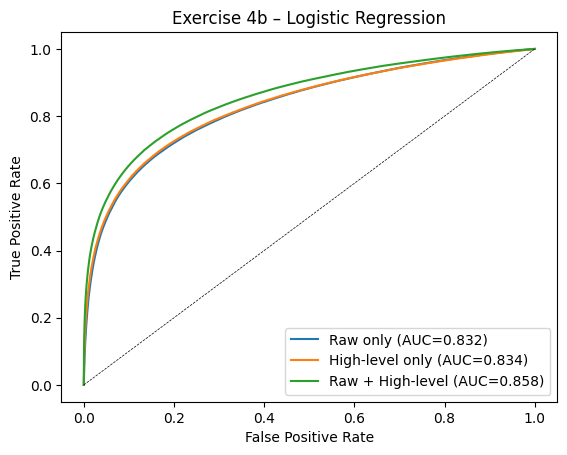

  Done. AUCs: {'Raw only': 0.8315635139476996, 'High-level only': 0.8341761915272117, 'Raw + High-level': 0.8580903630397982}
Training Hist Gradient Boosting...


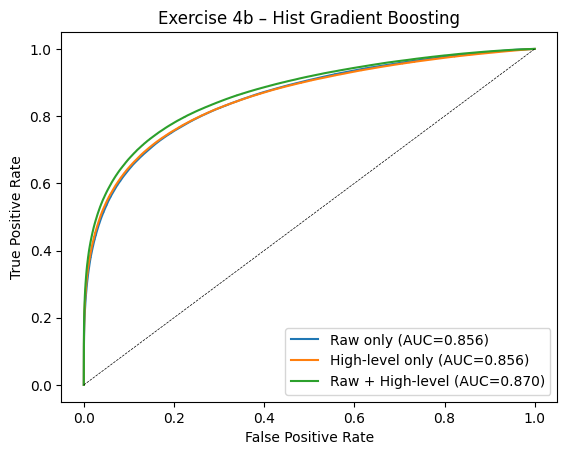

  Done. AUCs: {'Raw only': 0.8557646986199049, 'High-level only': 0.8557559880424274, 'Raw + High-level': 0.870075595988963}
Training Decision Tree (depth=5)...


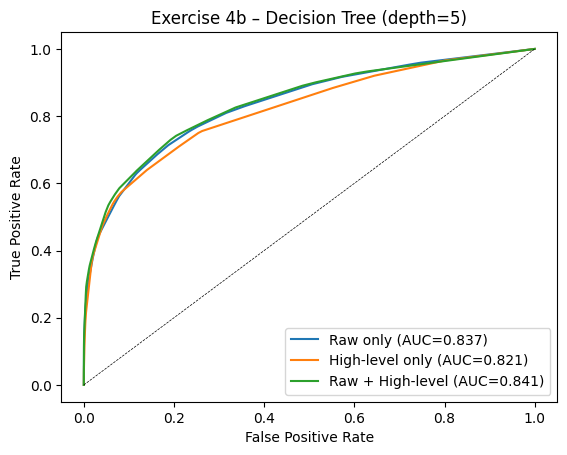

  Done. AUCs: {'Raw only': 0.836703150301201, 'High-level only': 0.8207075905193375, 'Raw + High-level': 0.8408738783183533}


In [25]:
#4.b
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

def compare_feature_sets(classifier, feature_sets, train_df, test_df, y_train, y_test, title=""):
    plt.figure()
    aucs = {}
    for label, feats in feature_sets.items():
        clf = classifier.__class__(**classifier.get_params())
        clf.fit(train_df[feats], y_train)
        scores = (clf.decision_function(test_df[feats]) if hasattr(clf, 'decision_function')
                  else clf.predict_proba(test_df[feats])[:, 1])
        fpr, tpr, _ = roc_curve(y_test, scores)
        roc_auc = auc(fpr, tpr)
        aucs[label] = roc_auc
        plt.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.3f})')
    plt.plot([0,1],[0,1], 'k--', linewidth=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()
    return aucs

# 3 classifiers
classifiers = {
    "Logistic Regression"       : LogisticRegression(max_iter=500),
    "Hist Gradient Boosting"    : HistGradientBoostingClassifier(max_iter=100, max_depth=3),
    "Decision Tree (depth=5)"   : DecisionTreeClassifier(max_depth=5),
}

all_aucs = {}
for clf_name, clf in classifiers.items():
    print(f"Training {clf_name}...")
    aucs = compare_feature_sets(
        clf, feature_sets, Train_Sample, Test_Sample, y_Train, y_Test,
        title=f"Exercise 4b – {clf_name}"
    )
    all_aucs[clf_name] = aucs
    print(f"  Done. AUCs: {aucs}")

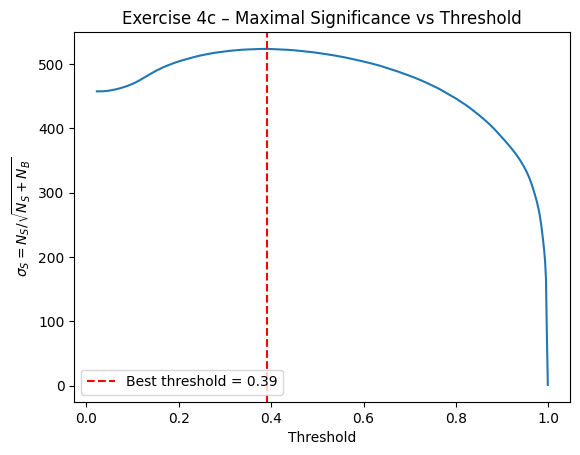

Max significance: 523.43 at threshold = 0.3905


In [27]:
#4.c
# Using HistGradientBoosting with all features (best performer, already trained above)
best_clf = HistGradientBoostingClassifier(max_iter=100, max_depth=3)
best_clf.fit(Train_Sample[all_features], y_Train)
scores = best_clf.predict_proba(X_Test)[:, 1]

thresholds    = np.linspace(scores.min(), scores.max(), 500)
significances = []
for t in thresholds:
    NS = ((scores >= t) & (y_Test == 1)).sum()
    NB = ((scores >= t) & (y_Test == 0)).sum()
    significances.append(NS / np.sqrt(NS + NB) if (NS + NB) > 0 else 0)

max_sig        = max(significances)
best_threshold = thresholds[np.argmax(significances)]

plt.figure()
plt.plot(thresholds, significances)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel("Threshold")
plt.ylabel(r"$\sigma_S = N_S / \sqrt{N_S + N_B}$")
plt.title("Exercise 4c – Maximal Significance vs Threshold")
plt.legend()
plt.show()

print(f"Max significance: {max_sig:.2f} at threshold = {best_threshold:.4f}")

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

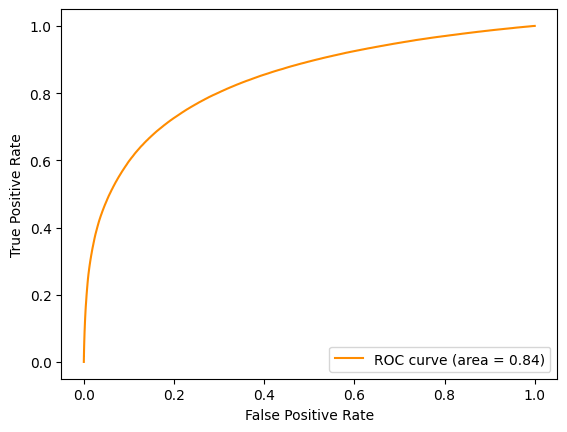

In [18]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


Metric,Value
AUC,0.8707
TPR / Recall,0.7894
FPR,0.21
Precision,0.7602
F1 Score,0.7745
Accuracy,0.7897
Max Significance,523.93


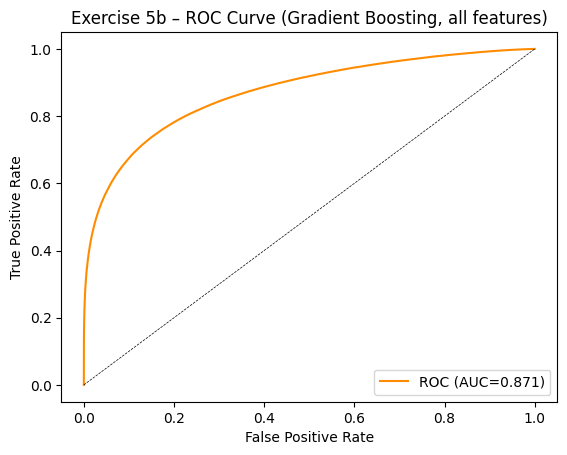

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Find optimal threshold (max significance) and get binary predictions
thresholds = np.linspace(scores.min(), scores.max(), 300)
sigs, preds_list = [], []
for t in thresholds:
    y_pred_t = (scores >= t).astype(int)
    NS = ((scores >= t) & (y_Test == 1)).sum()
    NB = ((scores >= t) & (y_Test == 0)).sum()
    sigs.append(NS / np.sqrt(NS + NB) if (NS + NB) > 0 else 0)

best_t = thresholds[np.argmax(sigs)]
y_pred = (scores >= best_t).astype(int)

fpr_arr, tpr_arr, _ = roc_curve(y_Test, scores)
roc_auc = auc(fpr_arr, tpr_arr)

rows = [
    ["AUC",             f"{roc_auc:.4f}"],
    ["TPR / Recall",    f"{recall_score(y_Test, y_pred):.4f}"],
    ["FPR",             f"{(y_pred[y_Test==0]==1).sum() / (y_Test==0).sum():.4f}"],
    ["Precision",       f"{precision_score(y_Test, y_pred):.4f}"],
    ["F1 Score",        f"{f1_score(y_Test, y_pred):.4f}"],
    ["Accuracy",        f"{accuracy_score(y_Test, y_pred):.4f}"],
    ["Max Significance",f"{max(sigs):.2f}"],
]

display(HTML(tabulate.tabulate(rows, headers=["Metric", "Value"], tablefmt="html")))

# Final ROC plot
plt.figure()
plt.plot(fpr_arr, tpr_arr, color='darkorange', label=f'ROC (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1], 'k--', linewidth=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exercise 5b – ROC Curve (Gradient Boosting, all features)')
plt.legend(loc='lower right')
plt.show()